# Preguntas

Para el heapmap tuve que sacar las variables cualitativas. 
Pero es justamente son esas las variables que presentan correlacion. Que puedo hacer? 


In [6]:
# instalamos el paquete para descargar archivos wget
#!pip install wget

from wget import download
from os import path, listdir

# descargamos la descripcion en TXT
if not path.exists("ObesityDataSet_raw_and_data_sinthetic.txt"):
  download("https://ignaciorlando.github.io/datasets/data-science/ObesityDataSet_raw_and_data_sinthetic.txt")
else:
  print("No vamos a bajar la descripcion porque ya existe!")

# descargamos una base de datos en CSV
if not path.exists("ObesityDataSet_raw_and_data_sinthetic.csv"):
  download("https://ignaciorlando.github.io/datasets/data-science/ObesityDataSet_raw_and_data_sinthetic.csv")
else:
  print("No vamos a bajar el archivo porque ya existe!")

# chequeamos si los archivos están en el directorio donde estamos parados
lista_archivos = listdir("./")
print(f"El contenido de la carpeta es: {lista_archivos}")


No vamos a bajar la descripcion porque ya existe!
No vamos a bajar el archivo porque ya existe!
El contenido de la carpeta es: ['amb-tp3', 'ej1.ipynb', 'ObesityDataSet_raw_and_data_sinthetic.csv', 'ObesityDataSet_raw_and_data_sinthetic.txt', 'ObesityDataSet_raw_and_data_sinthetic (1).csv']


In [4]:
#!pip install pandas 
import pandas as pd

# abrimos el archivo usando una función específica de pandas
raw_dataset = pd.read_csv("ObesityDataSet_raw_and_data_sinthetic.csv")
raw_dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             2111 non-null   float64
 1   Gender                          2111 non-null   str    
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   CALC                            2111 non-null   str    
 5   FAVC                            2111 non-null   str    
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   SCC                             2111 non-null   str    
 9   SMOKE                           2111 non-null   str    
 10  CH2O                            2111 non-null   float64
 11  family_history_with_overweight  2111 non-null   str    
 12  FAF                             2111 non-null

Feature: Age                                 |▌         | [  6%]   00:00 -> (00:00 left)findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
Feature: Gender                              |█         | [ 11%]   00:00 -> (00:02 left)findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal,


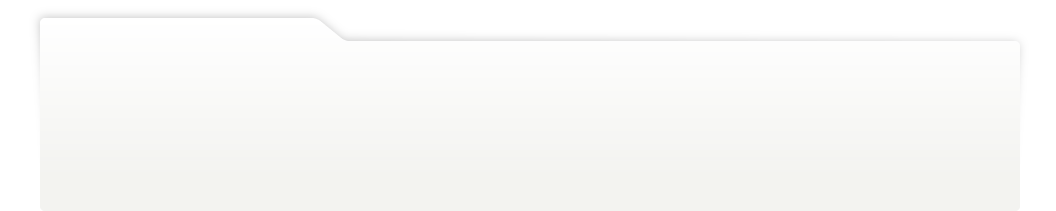
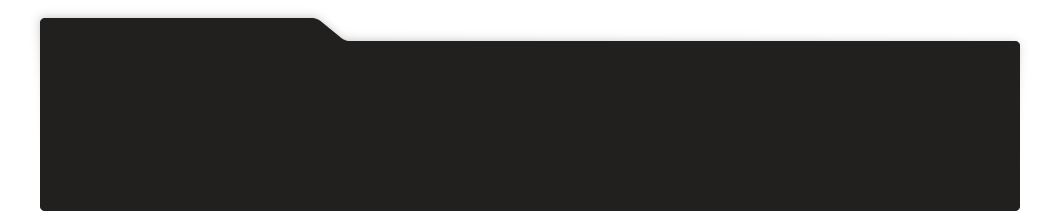
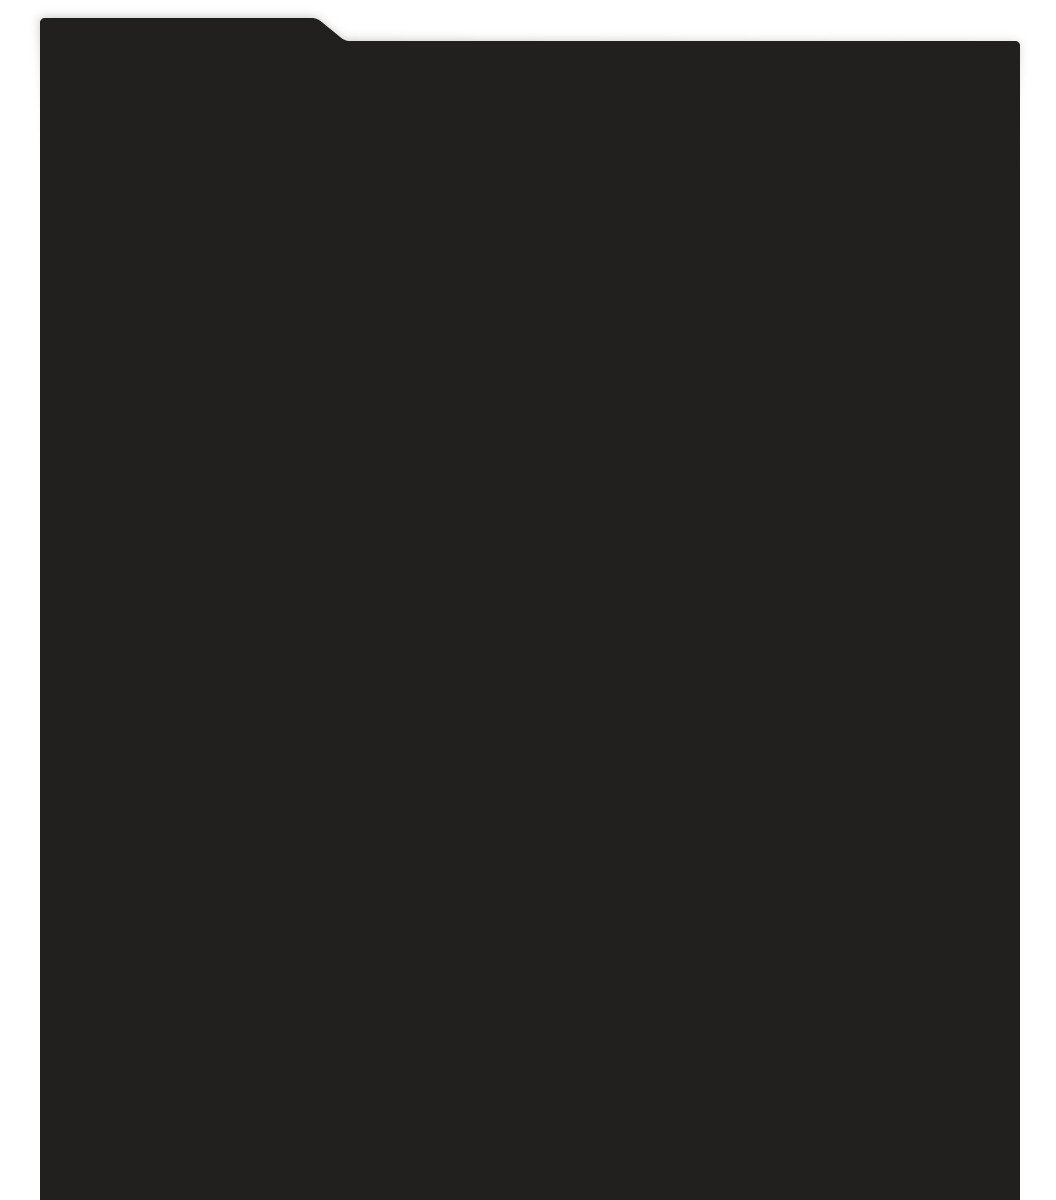
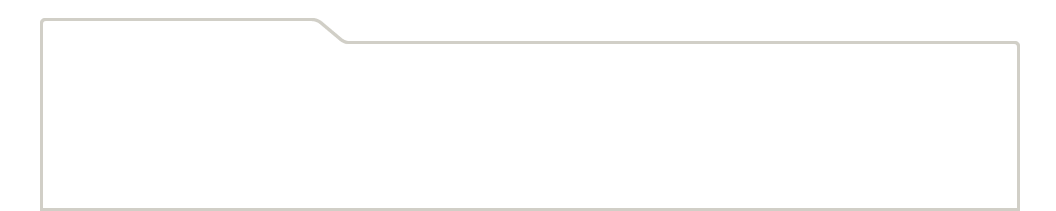
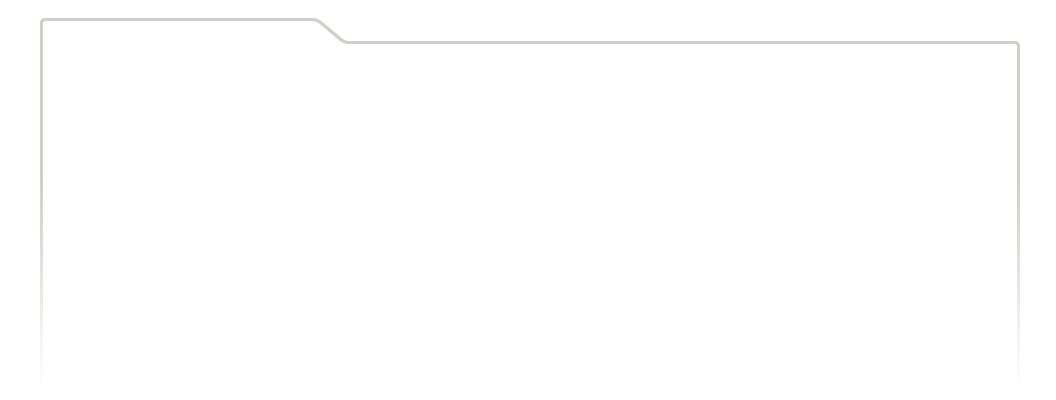
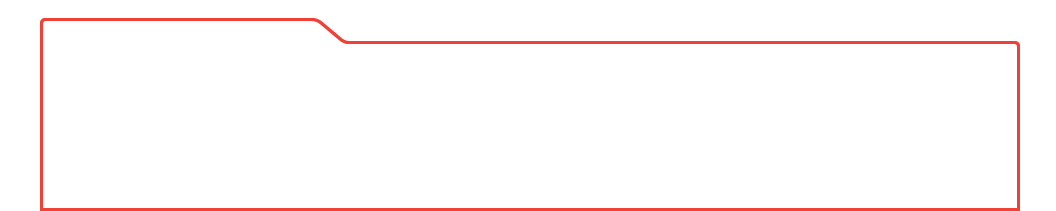
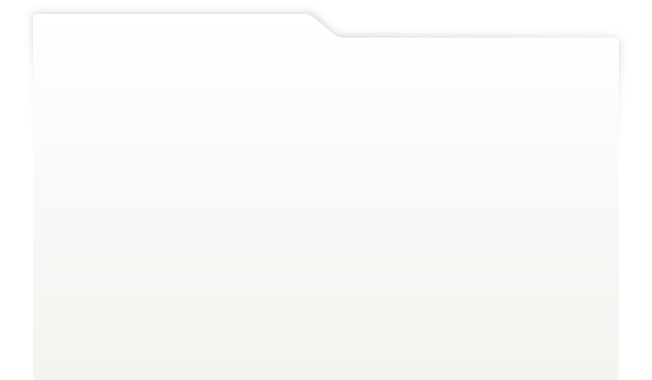
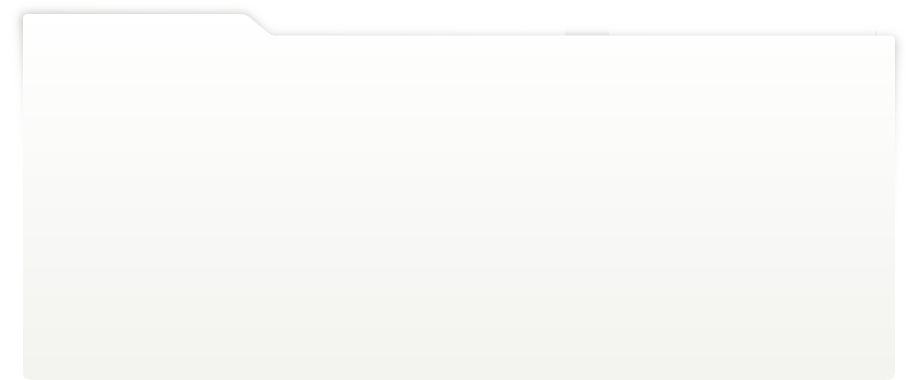
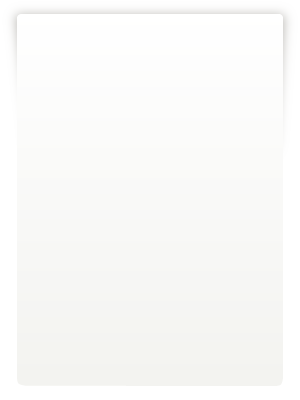
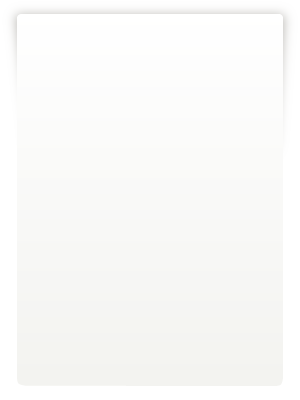
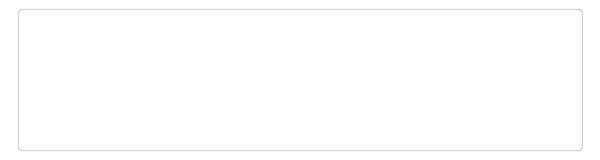
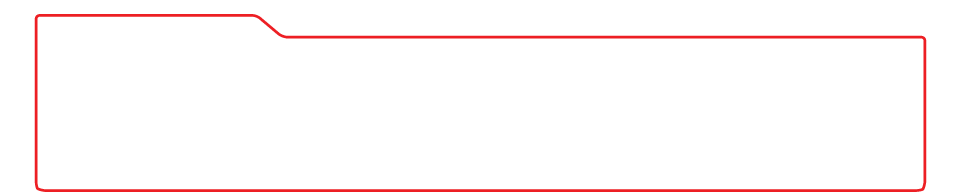
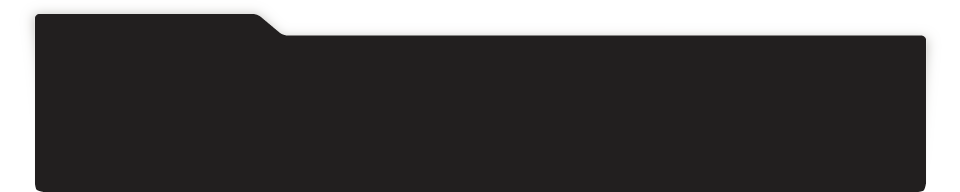
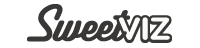
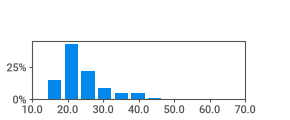
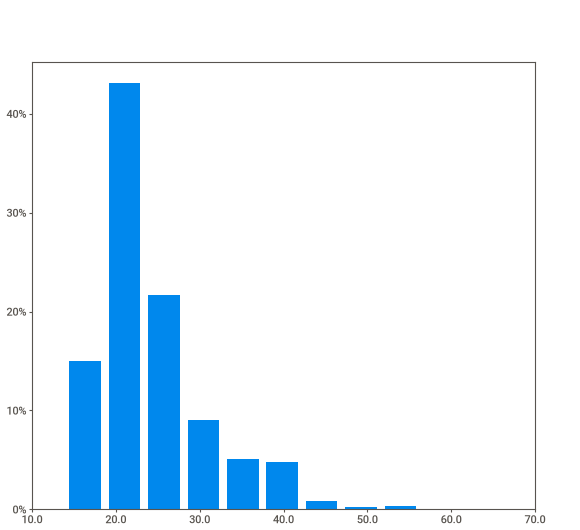
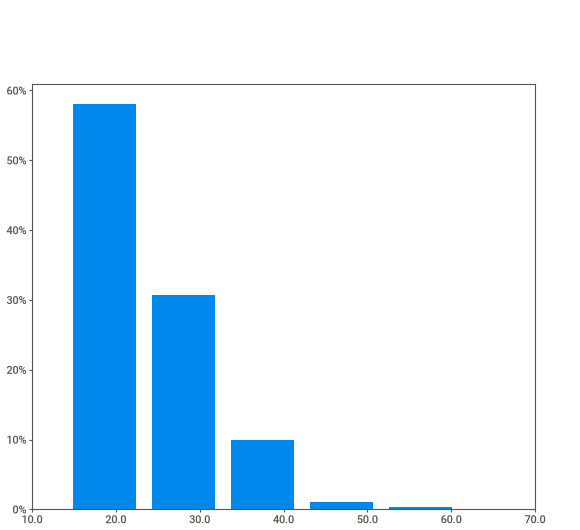
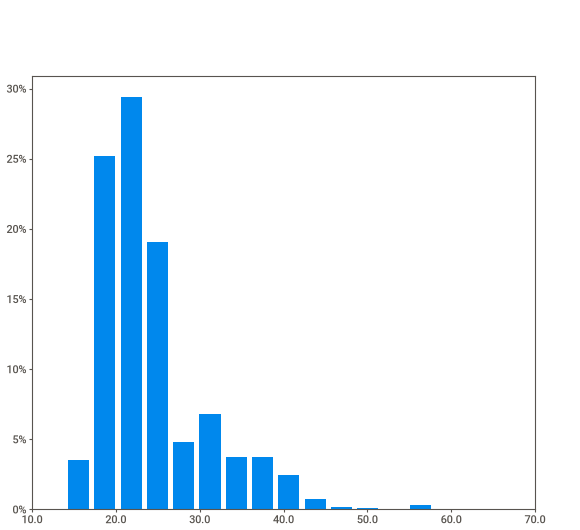
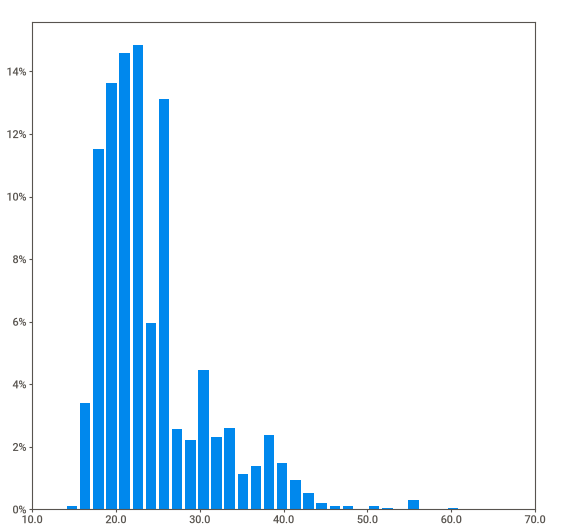
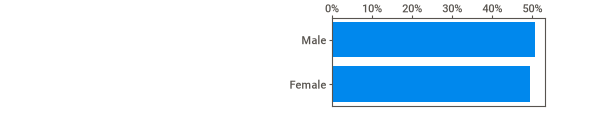
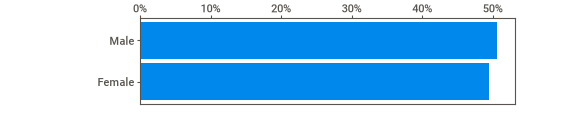
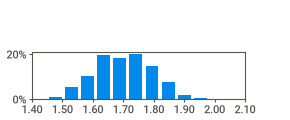
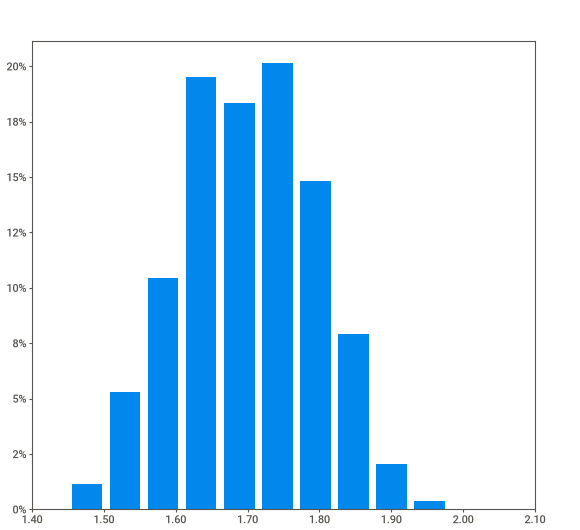
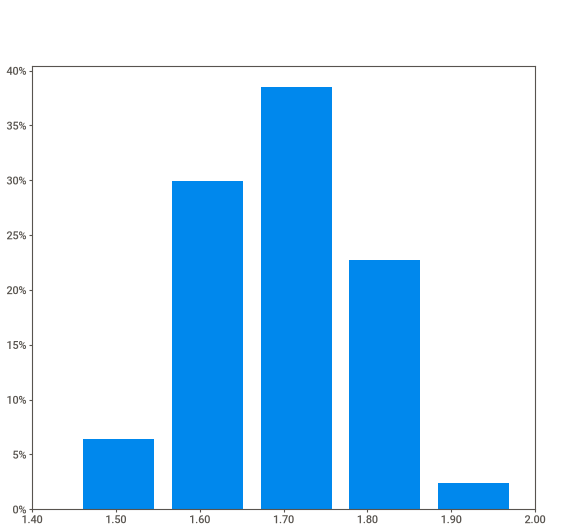
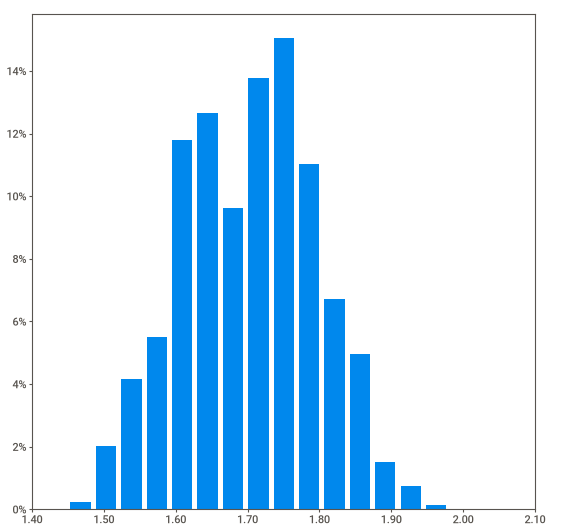
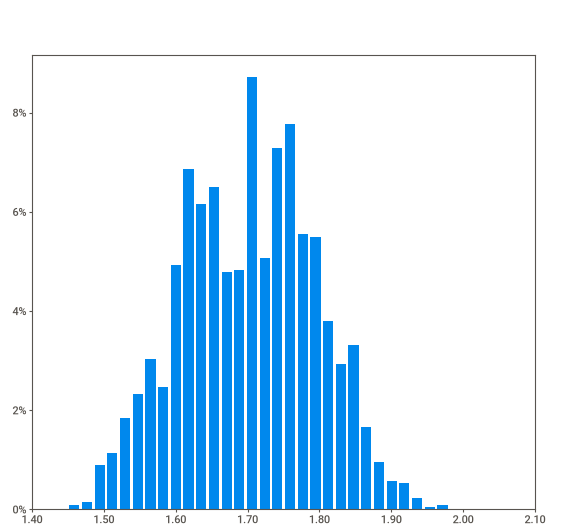
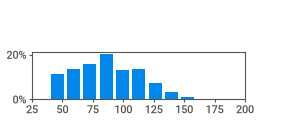
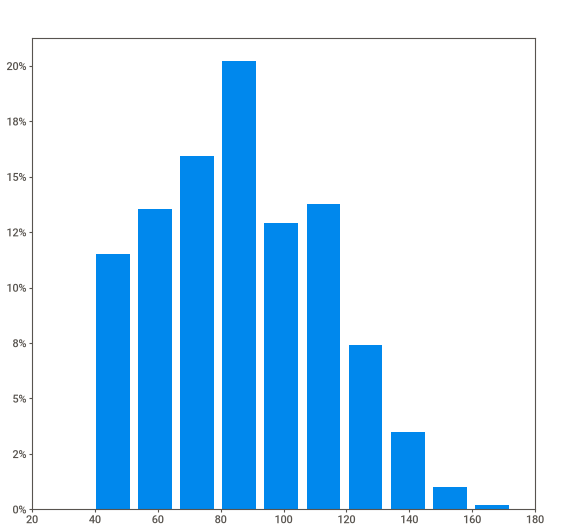
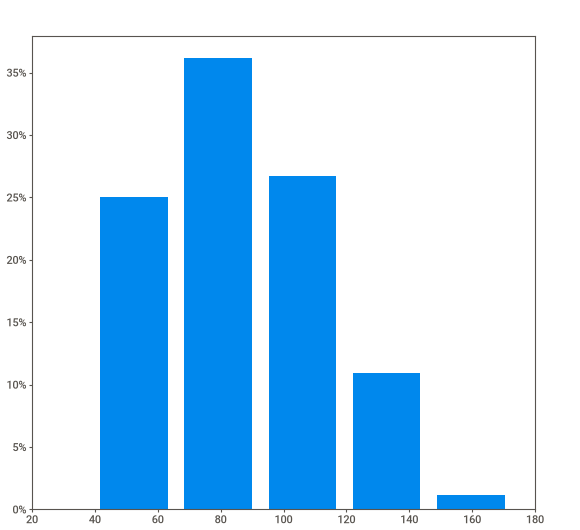
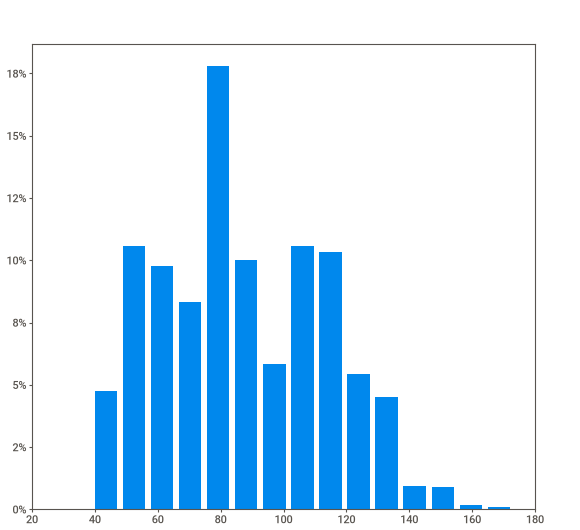
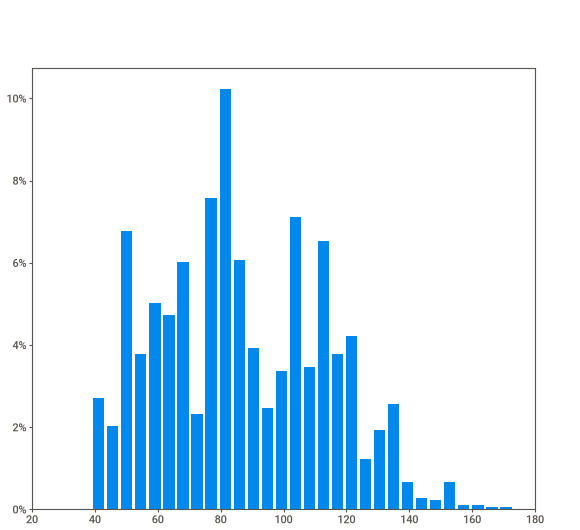
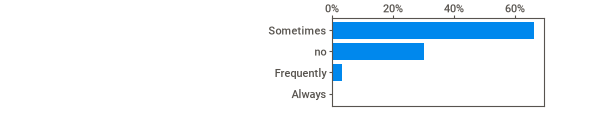
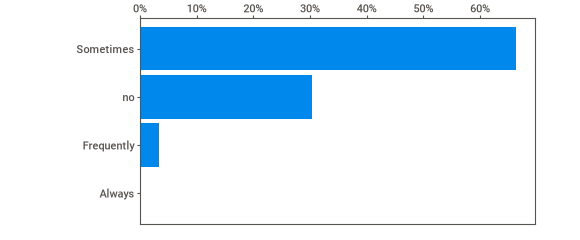
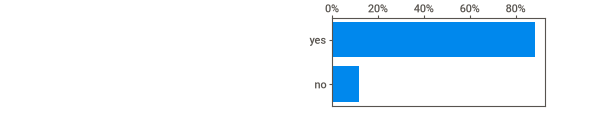
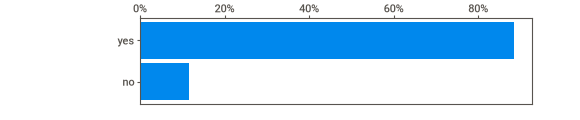
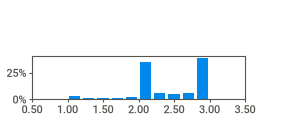
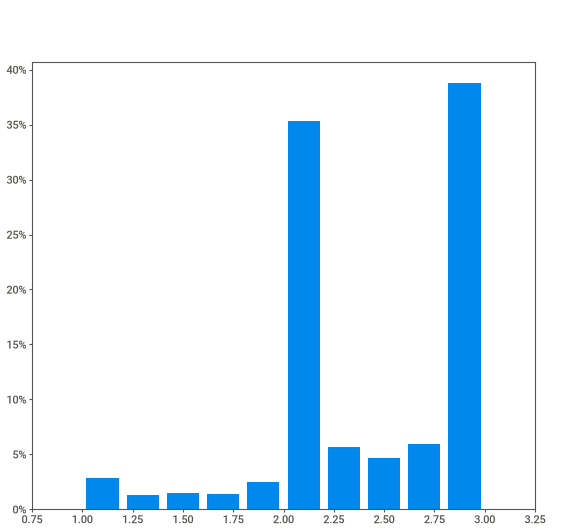
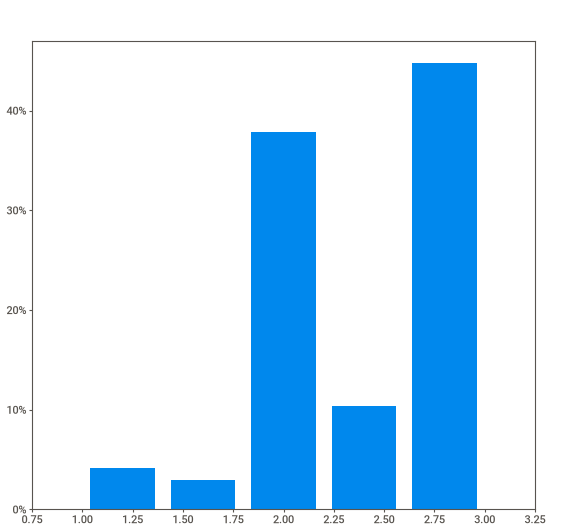
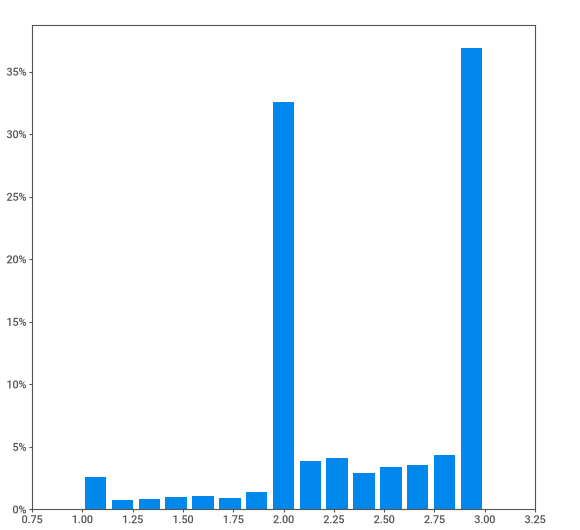
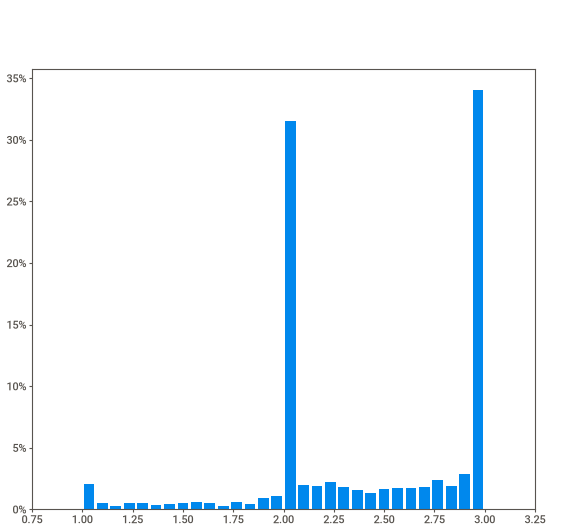
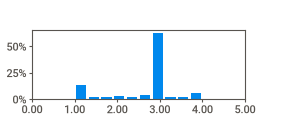
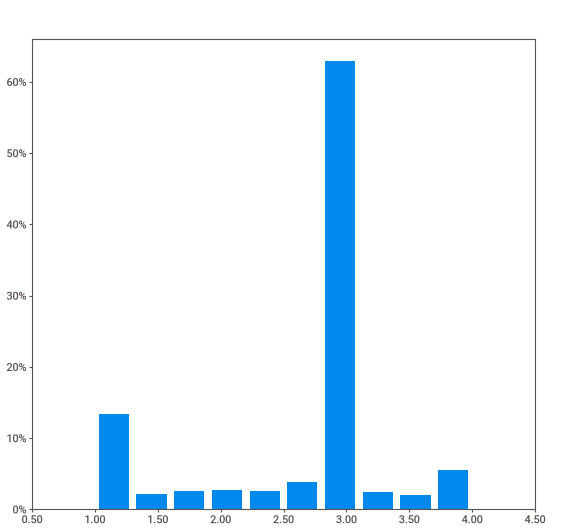
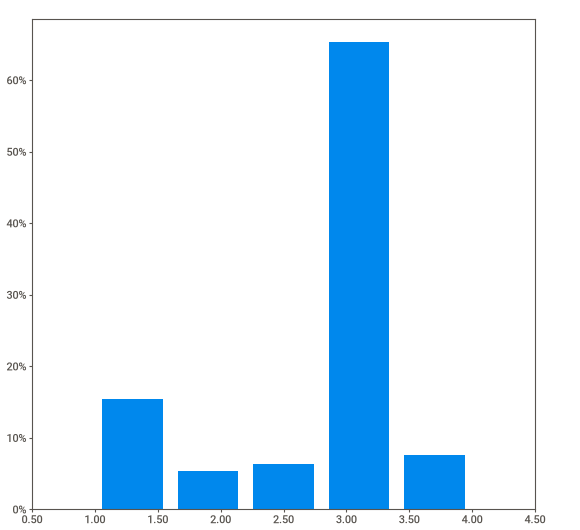
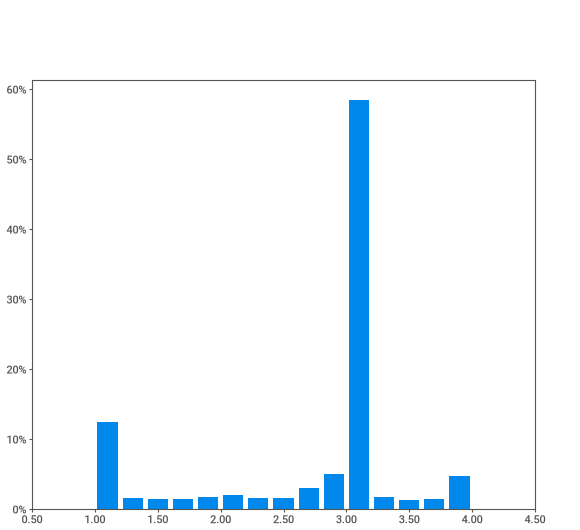
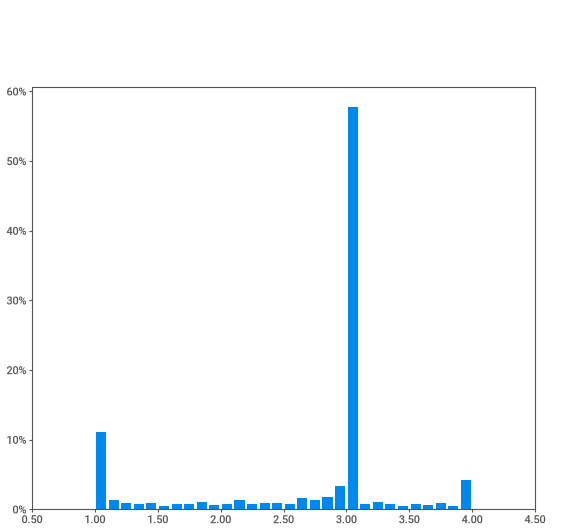
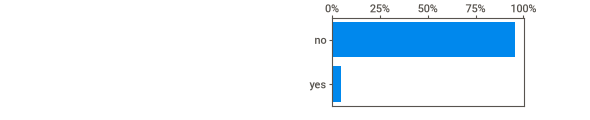
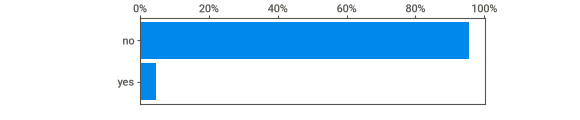
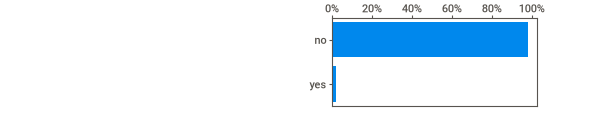
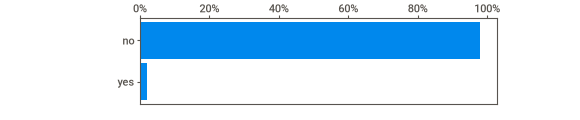
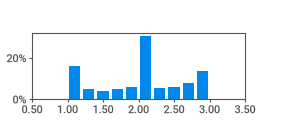
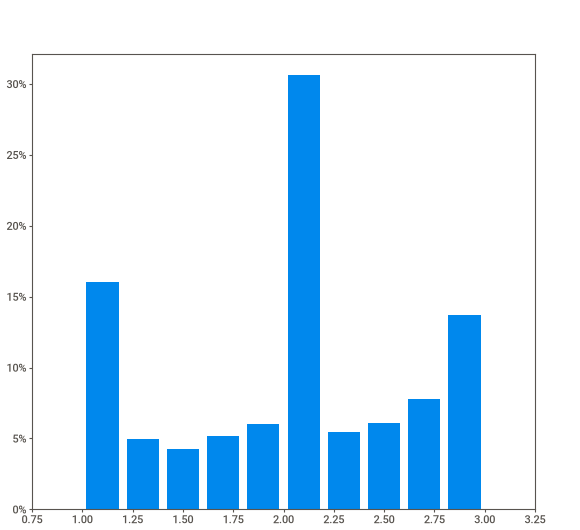
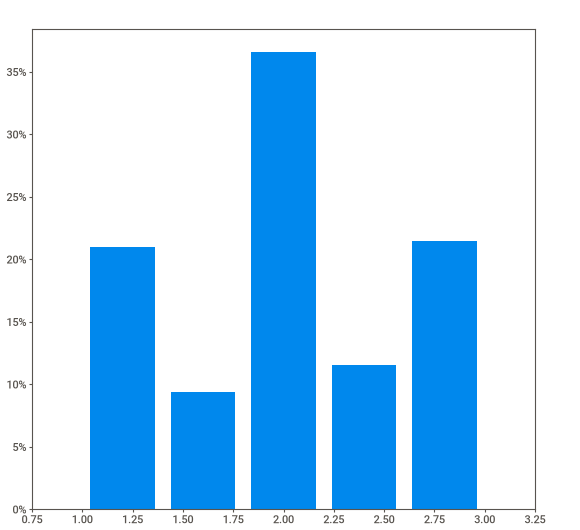
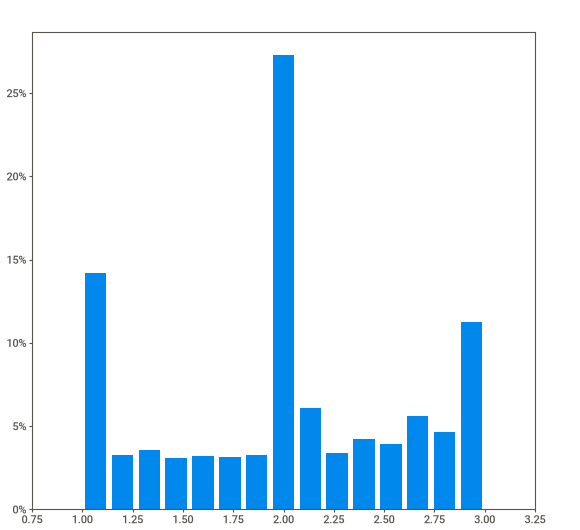
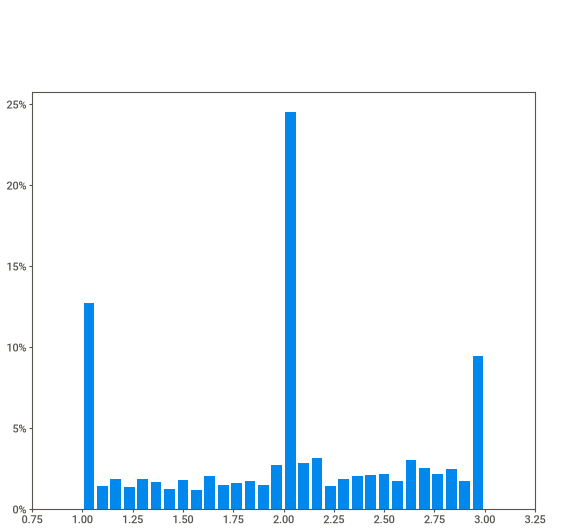
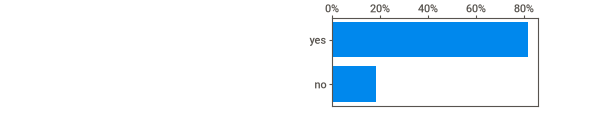
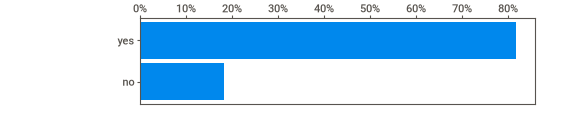
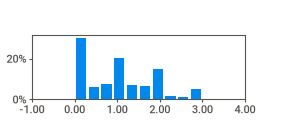
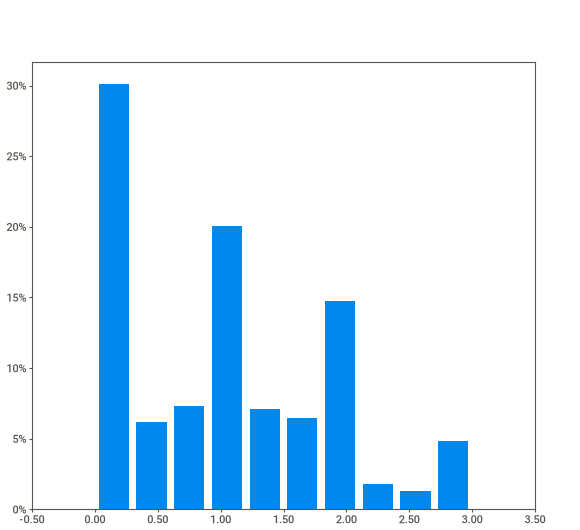
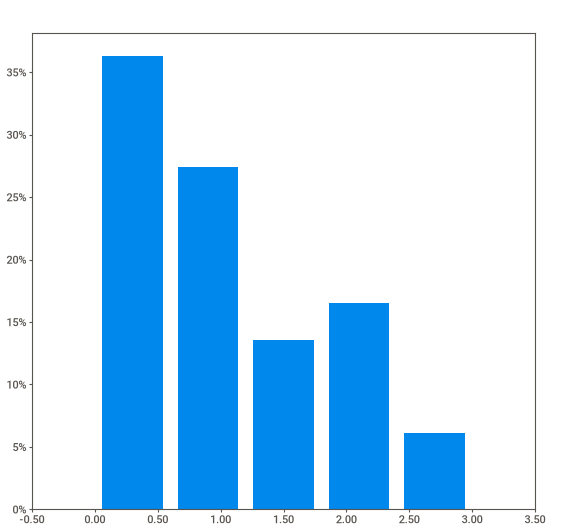
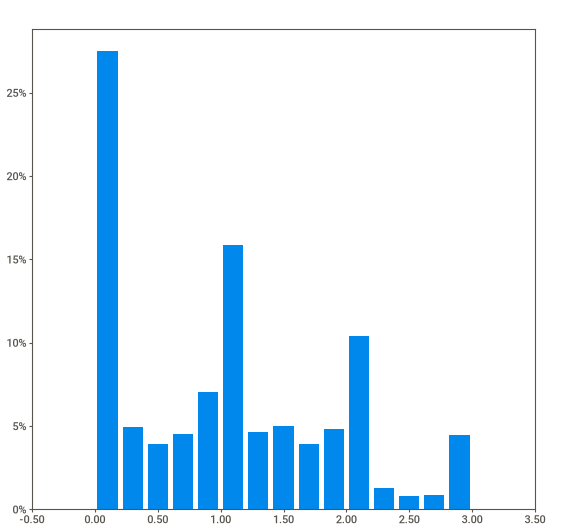
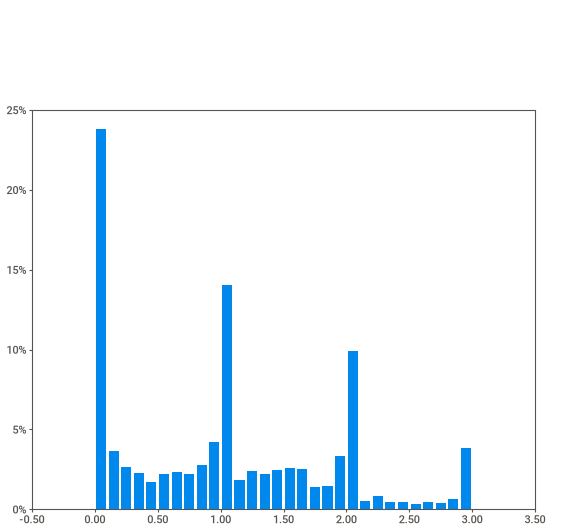
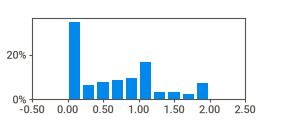
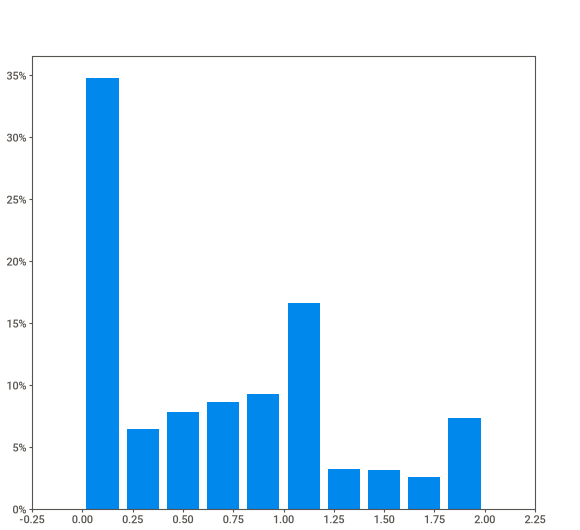
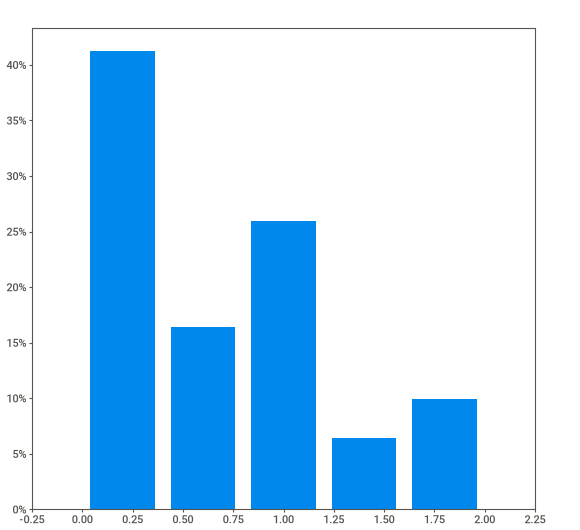
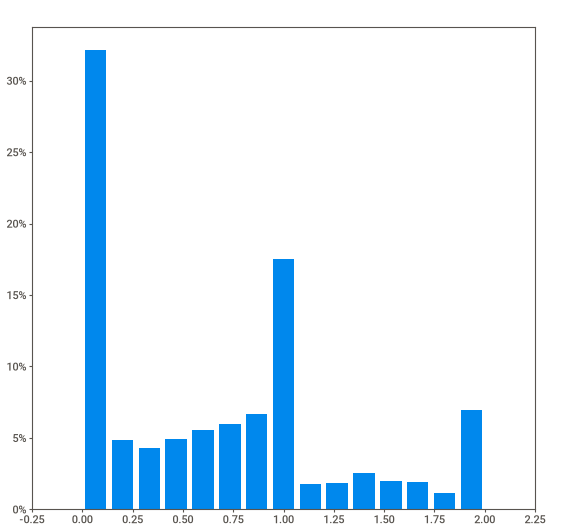
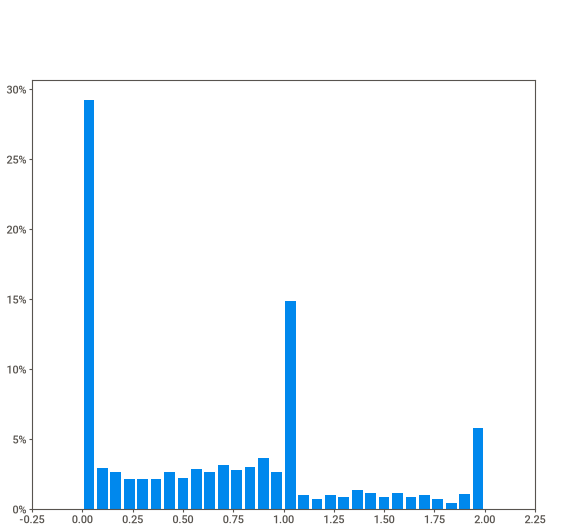
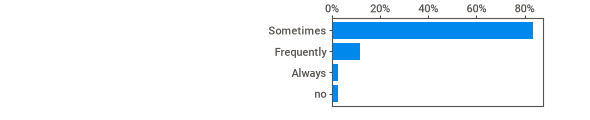
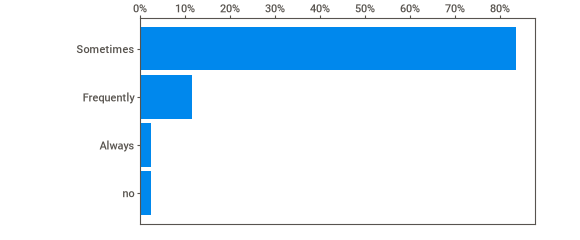
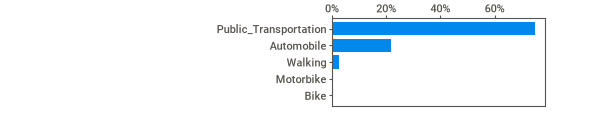
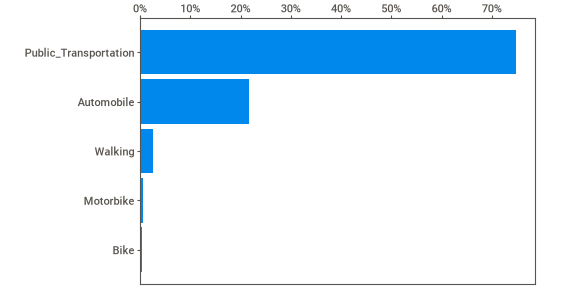
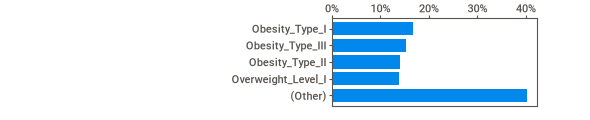
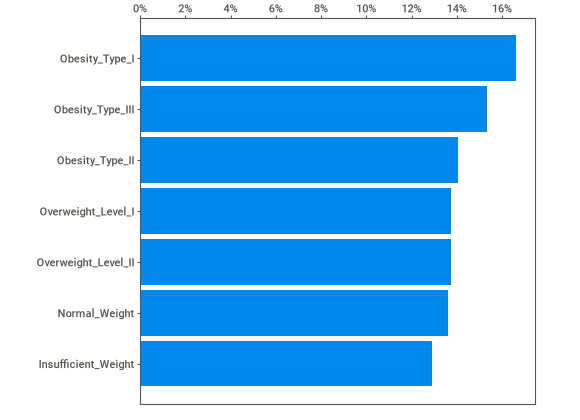
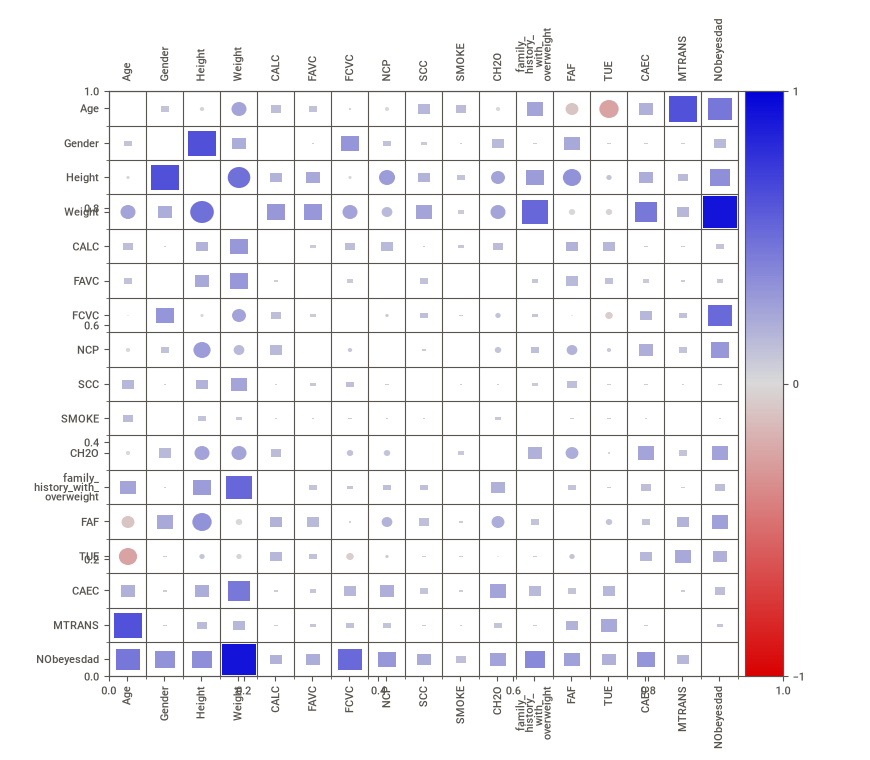
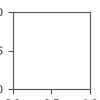

In [10]:
#!pip install sweetviz
import sweetviz as sv

reporte = sv.analyze(raw_dataset)

#reporte.show_html("reporte.html")
reporte.show_notebook()


In [ ]:
import pandas as pd
import ydata_profiling as pp

# generamos el reporte
report = pp.ProfileReport(raw_dataset)
# lo mostramos interactivo en nuestra notebook
report.to_notebook_iframe()

# Matriz de correlacion
Una manera de resumir todas las posibles relaciones es construyendo una matriz de correlación, donde presentemos todos los valores de correlación entre todos los posibles pares de variables.

Olvídense de tener que hacer eso iterando con un doble for. Podemos hacerlo directamente en Pandas, usando el método corr(). El método calcula un tipo de correlación que nosotros le digamos según el parámetro method (que es opcional y por defecto está seteada en Pearson, pero también podría ser Kendall o Spearman o incluso una función que nosotros programemos), ignorando en todos los casos si hay un valor faltante.

In [15]:
correlation_matrix = raw_dataset.corr(numeric_only=True)
correlation_matrix

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
Age,1.000000,-0.025958,0.202560,0.016291,-0.043944,-0.045304,-0.144938,-0.296931
Height,-0.025958,1.000000,0.463136,-0.038121,0.243672,0.213376,0.294709,0.051912
Weight,0.202560,0.463136,1.000000,0.216125,0.107469,0.200575,-0.051436,-0.071561
FCVC,0.016291,-0.038121,0.216125,1.000000,0.042216,0.068461,0.019939,-0.101135
NCP,-0.043944,0.243672,0.107469,0.042216,1.000000,0.057088,0.129504,0.036326
CH2O,-0.045304,0.213376,0.200575,0.068461,0.057088,1.000000,0.167236,0.011965
FAF,-0.144938,0.294709,-0.051436,0.019939,0.129504,0.167236,1.000000,0.058562
TUE,-0.296931,0.051912,-0.071561,-0.101135,0.036326,0.011965,0.058562,1.000000


# HeatMap

Si quisiéramos por ejemplo identificar más fácilmente los casos de correlaciones elevadas o bajas, podríamos representar esta matriz gráficamente, asignando colores a cada uno de los valores. Podríamos, por ejemplo, usar un color neutro para los valores cercanos a cero, y transicionar hacia valores más fuertes cuando nos aproximamos a -1 o 1.

Esto es lo que se conoce como "mapa de calor", o heatmap en inglés. La librería Seaborn (una que vamos a usar para la gran mayoría de nuestras visualizaciones, montaba sobre otra también muy útil, Matplotlib) lo incluye con el nombre heatmap y es bastante fácil de usar, solamente nos pide que pasemos la matriz, un valor mínimo vmin, un máximo vmax y el valor central center, y a partir de un mapa de colores cmap nos representará la matriz, incluyendo anotaciones si le passamos anot en True:

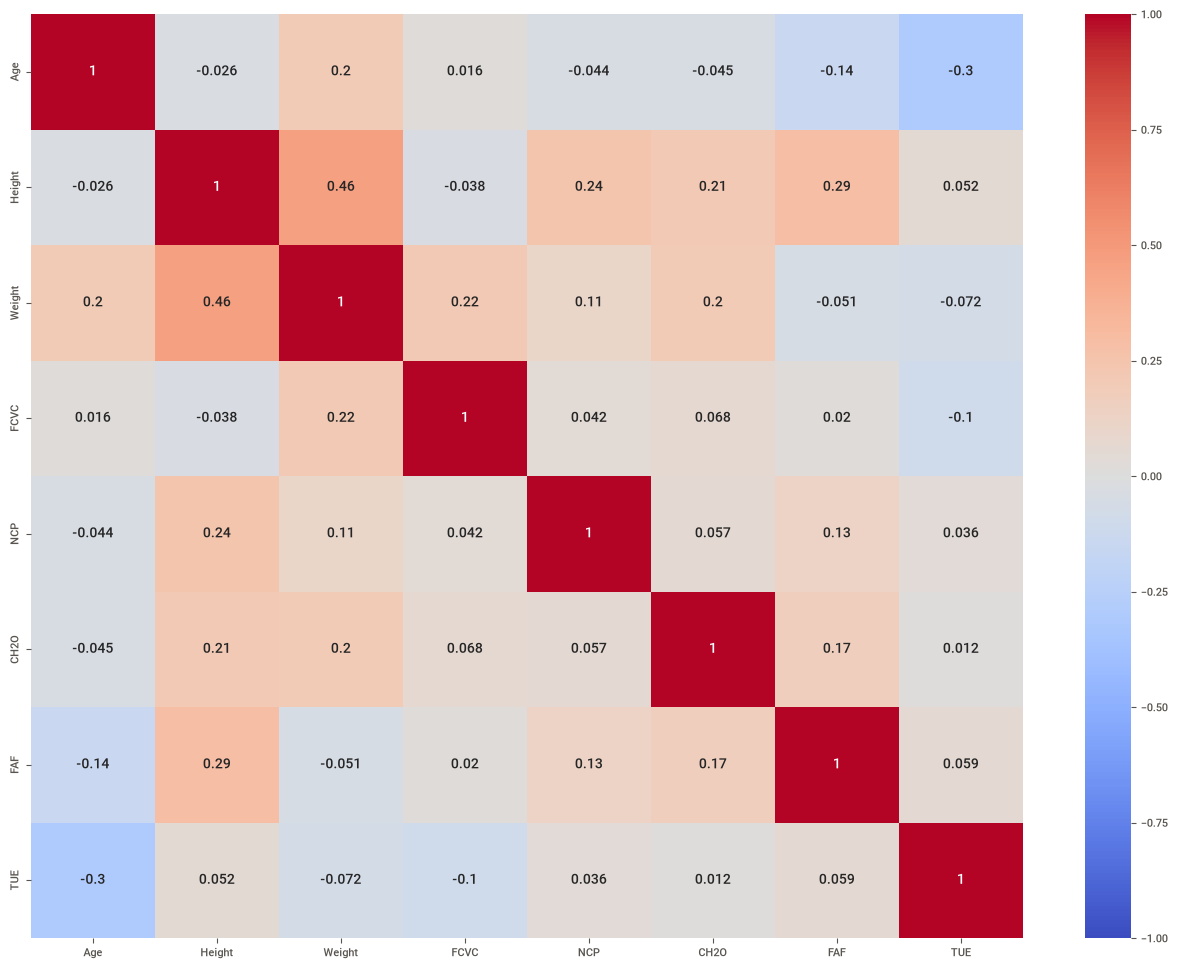

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# imprimimos la matriz como un heatmap
plt.figure(figsize=(16,12))
sns.heatmap(correlation_matrix, vmin=-1.0, vmax=1.0, center=0.0, annot=True, cmap= 'coolwarm')
plt.show()

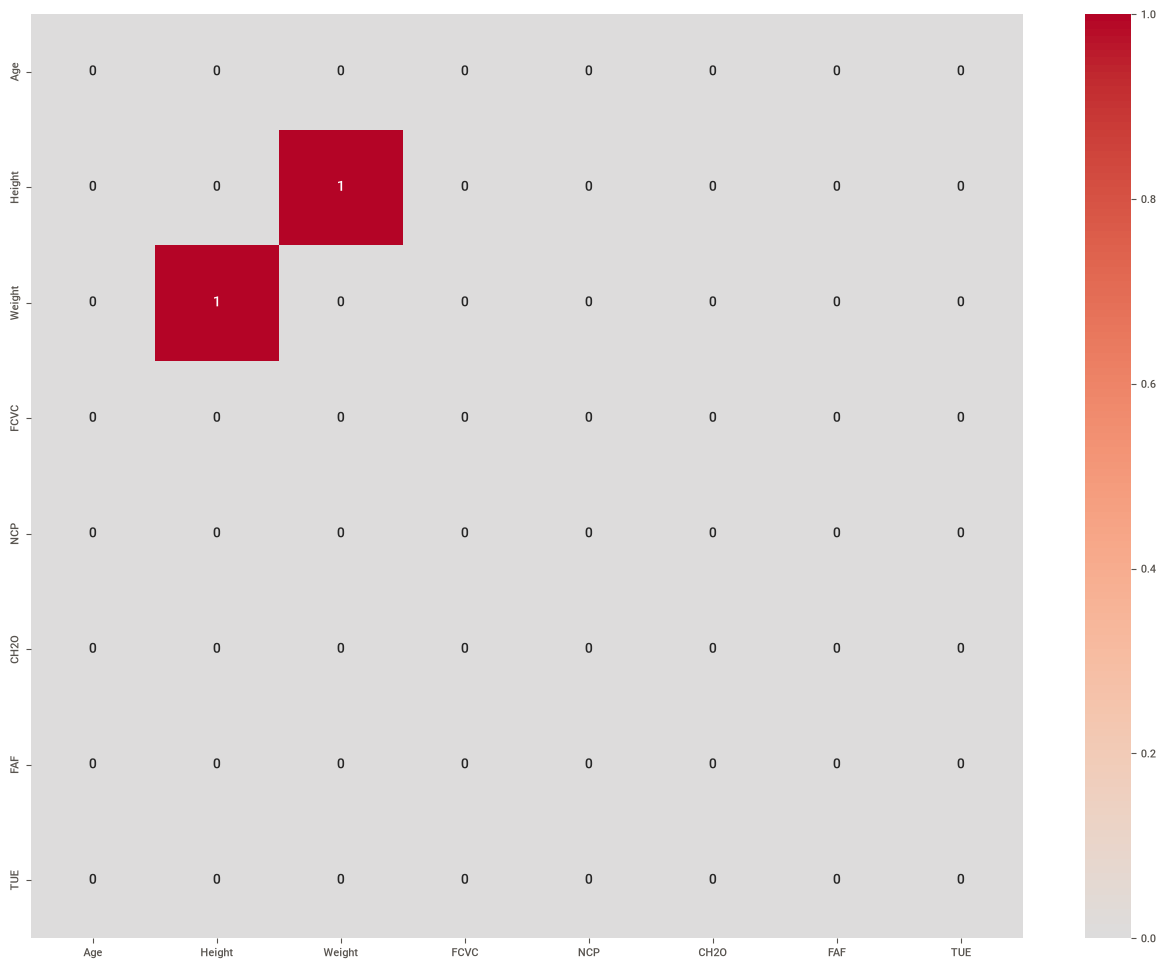

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# tomamos el valor absoluto de las correlaciones, umbralamos las mayores a 0.7
# El .astype(int) crea un DataFrame nuevo que SÍ es modificable para que fill diagonal pueda funcionar
umbral = 0.3
correlation_matrix_umbralizada = (correlation_matrix.abs() > umbral).astype(int)

# 2. Extraemos los datos forzando una COPIA desvinculada del DataFrame original
arr_modificable = correlation_matrix_umbralizada.to_numpy(copy=True)

# aprovechamos y sacamos la diagonal
np.fill_diagonal(arr_modificable, 0)

# 4. Volvemos a meter esos números en un DataFrame para que el heatmap tenga las etiquetas
correlation_matrix_umbralizada = pd.DataFrame(
    arr_modificable, 
    index=correlation_matrix.index, 
    columns=correlation_matrix.columns
)

# e imprimimos la matriz como un heatmap
plt.figure(figsize=(16,12))
sns.heatmap(correlation_matrix_umbralizada, vmin=0.0, vmax=1.0, center=0.0, annot=True, cmap= 'coolwarm')
plt.show()

# Hipotesis - como se relaciona la obesidad con la edad

Tener en cuenta que el dataset presenta alta concentracion de edades con tendencia a los 20s

/tmp/ipykernel_50746/1899926752.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=raw_dataset, x=row, y=col, palette='coolwarm')
findfont: Failed to find font weight normal, now using 500.


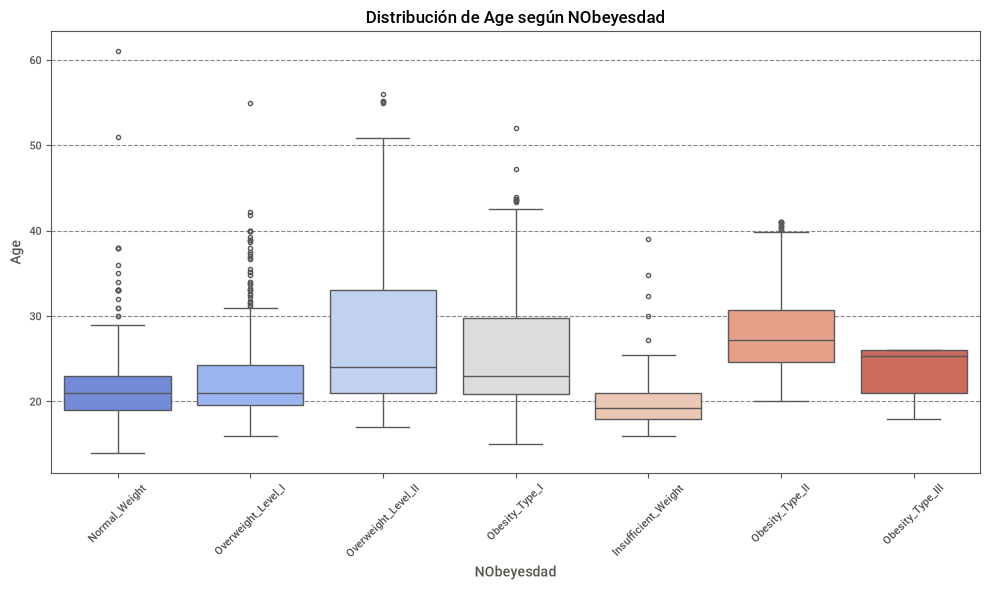

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

# Asumo que 'wo' era en realidad 'col'
row = 'NObeyesdad'
col = 'Age'

# Hacemos el gráfico un poco más ancho (10, 6) para que entren bien las categorías
plt.figure(figsize=(10, 6))

# Creamos el boxplot usando seaborn
sns.boxplot(data=raw_dataset, x=row, y=col, palette='coolwarm')

# y lo mostramos bonito
plt.title(f"Distribución de {col} según {row}")
plt.xlabel(row)
plt.ylabel(col)

# ¡Truco clave! Rotamos las etiquetas del eje X 45 grados. 
# Como las categorías de "NObeyesdad" suelen ser textos largos, así evitamos que se superpongan.
plt.xticks(rotation=45)

# Ponemos una grilla sutil solo en el eje Y para facilitar la lectura de las edades
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

# Ajustamos los márgenes automáticamente para que no se corte ningún texto
plt.tight_layout() 

plt.show()

# Hipotesis - El transporte influye en el peso

no parece estar relacionado

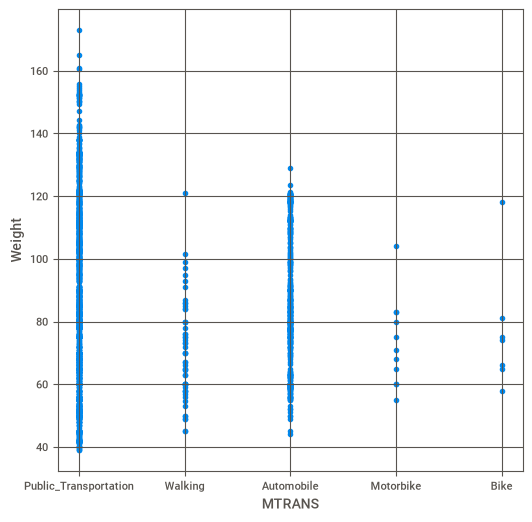

In [39]:
# representamos en un scatter plot cuadrado los valores de ambas variables

row = 'MTRANS'
col = 'Weight'

plt.figure(figsize=(6, 6))
plt.scatter(raw_dataset[row], raw_dataset[col])

# y lo mostramos bonito
#plt.title(f"Scatter plot entre {col} y {row} - r = {correlation:.4f}")
plt.xlabel(row)
plt.ylabel(col)
plt.grid(True)
plt.show()

# Hipotesis - Comer entre comidas influye en el peso

/tmp/ipykernel_50746/3918905310.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=raw_dataset, x=row, y=col, palette='coolwarm')


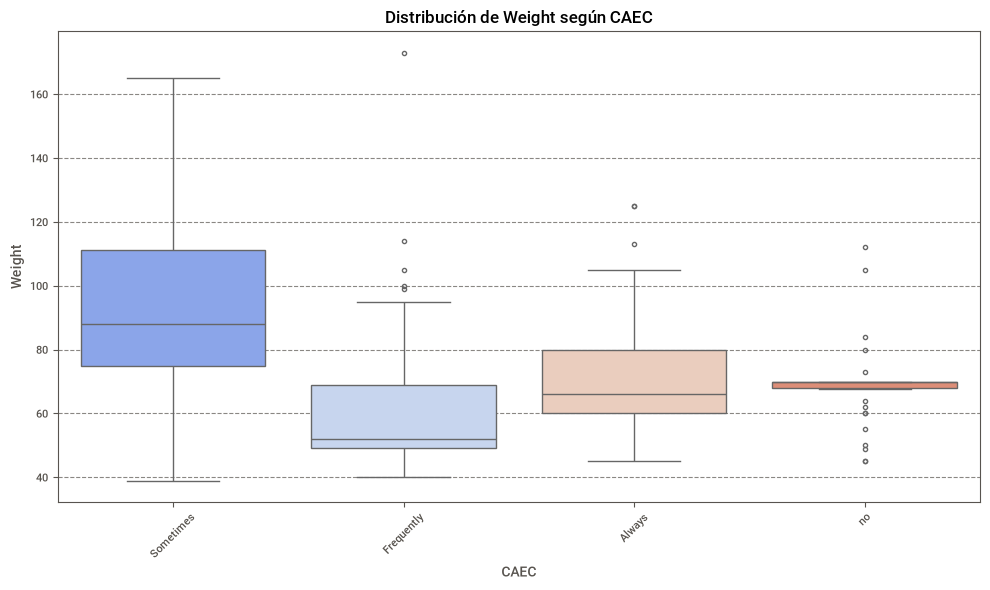

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

# Asumo que 'wo' era en realidad 'col'
row = 'CAEC'
col = 'Weight'

# Hacemos el gráfico un poco más ancho (10, 6) para que entren bien las categorías
plt.figure(figsize=(10, 6))

# Creamos el boxplot usando seaborn
sns.boxplot(data=raw_dataset, x=row, y=col, palette='coolwarm')

# y lo mostramos bonito
plt.title(f"Distribución de {col} según {row}")
plt.xlabel(row)
plt.ylabel(col)

# ¡Truco clave! Rotamos las etiquetas del eje X 45 grados. 
# Como las categorías de "NObeyesdad" suelen ser textos largos, así evitamos que se superpongan.
plt.xticks(rotation=45)

# Ponemos una grilla sutil solo en el eje Y para facilitar la lectura de las edades
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

# Ajustamos los márgenes automáticamente para que no se corte ningún texto
plt.tight_layout() 

plt.show()

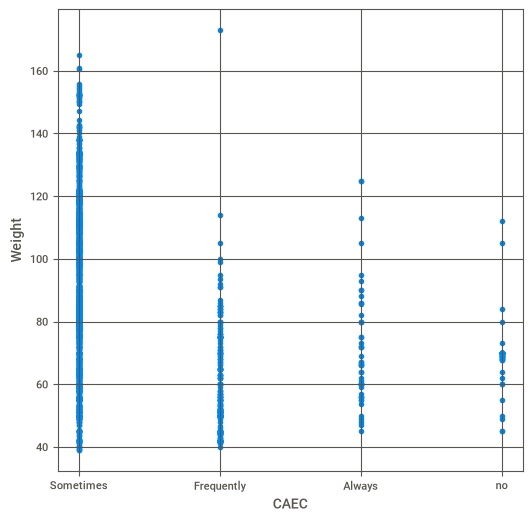

In [40]:


row = 'CAEC'
col = 'Weight'

plt.figure(figsize=(6, 6))
plt.scatter(raw_dataset[row], raw_dataset[col])

# y lo mostramos bonito
#plt.title(f"Scatter plot entre {col} y {row} - r = {correlation:.4f}")
plt.xlabel(row)
plt.ylabel(col)
plt.grid(True)
plt.show()

# Hipotesis - La ingesta de vegetales influye en el peso

/tmp/ipykernel_50746/4283880334.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=raw_dataset, x=row, y=col, palette='coolwarm')


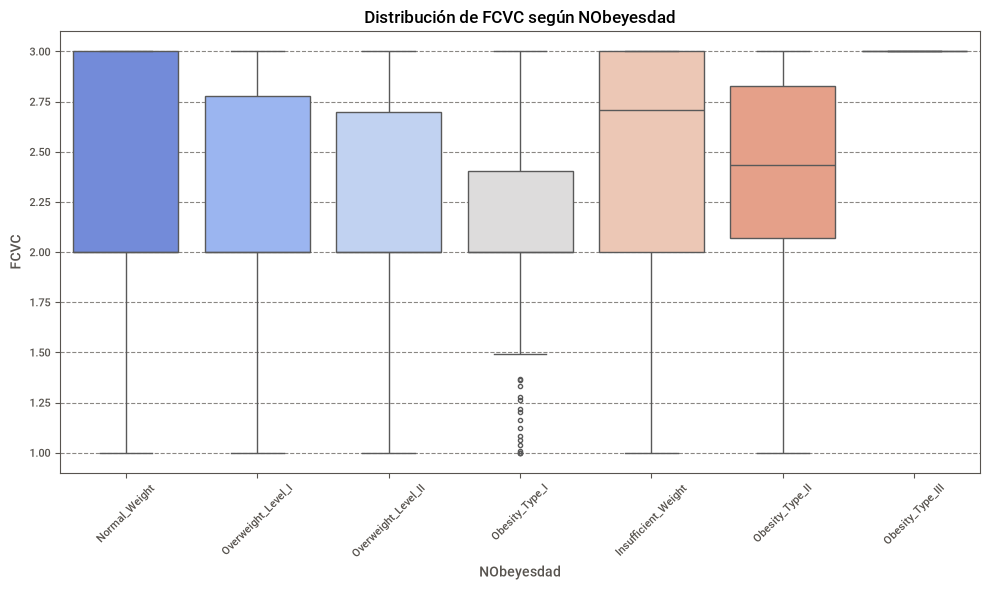

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

# Asumo que 'wo' era en realidad 'col'
row = 'NObeyesdad'
col = 'FCVC'

# Hacemos el gráfico un poco más ancho (10, 6) para que entren bien las categorías
plt.figure(figsize=(10, 6))

# Creamos el boxplot usando seaborn
sns.boxplot(data=raw_dataset, x=row, y=col, palette='coolwarm')

# y lo mostramos bonito
plt.title(f"Distribución de {col} según {row}")
plt.xlabel(row)
plt.ylabel(col)

# ¡Truco clave! Rotamos las etiquetas del eje X 45 grados. 
# Como las categorías de "NObeyesdad" suelen ser textos largos, así evitamos que se superpongan.
plt.xticks(rotation=45)

# Ponemos una grilla sutil solo en el eje Y para facilitar la lectura de las edades
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

# Ajustamos los márgenes automáticamente para que no se corte ningún texto
plt.tight_layout() 

plt.show()